In [8]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("Segmentacion_Perfilado_Clientes") \
    .getOrCreate()

clientes_df = spark.read.parquet("/home/jovyan/work/data/CLIENTS", header=True, inferSchema=True)
behavioural_df = spark.read.parquet("/home/jovyan/work/data/BEHAVIOURAL", header=True, inferSchema=True)

In [3]:
behavioural_df

DataFrame[CONTRACT_ID: string, CLIENT_ID: string, DATE: date, CREDICT_CARD_BALANCE: double, CREDIT_CARD_LIMIT: double, CREDIT_CARD_DRAWINGS_ATM: double, CREDIT_CARD_DRAWINGS: double, CREDIT_CARD_DRAWINGS_POS: double, CREDIT_CARD_DRAWINGS_OTHER: double, CREDIT_CARD_PAYMENT: double, NUMBER_DRAWINGS_ATM: double, NUMBER_DRAWINGS: int, NUMBER_INSTALMENTS: double, CURRENCY: string]

In [4]:
clientes_df

DataFrame[CLIENT_ID: string, NON_COMPLIANT_CONTRACT: int, NAME_PRODUCT_TYPE: string, GENDER: string, TOTAL_INCOME: double, AMOUNT_PRODUCT: double, INSTALLMENT: double, EDUCATION: string, MARITAL_STATUS: string, HOME_SITUATION: string, REGION_SCORE: double, AGE_IN_YEARS: double, JOB_SENIORITY: double, HOME_SENIORITY: double, LAST_UPDATE: double, OWN_INSURANCE_CAR: string, CAR_AGE: double, FAMILY_SIZE: double, REACTIVE_SCORING: double, PROACTIVE_SCORING: double, BEHAVIORAL_SCORING: double, DAYS_LAST_INFO_CHANGE: double, NUMBER_OF_PRODUCTS: double, OCCUPATION: string, DIGITAL_CLIENT: int, HOME_OWNER: string, EMPLOYER_ORGANIZATION_TYPE: string, CURRENCY: string, NUM_PREVIOUS_LOAN_APP: double, LOAN_ANNUITY_PAYMENT_MAX: double, LOAN_ANNUITY_PAYMENT_MIN: double, LOAN_ANNUITY_PAYMENT_SUM: double, LOAN_APPLICATION_AMOUNT_MAX: double, LOAN_APPLICATION_AMOUNT_MIN: double, LOAN_APPLICATION_AMOUNT_SUM: double, LOAN_CREDIT_GRANTED_MAX: double, LOAN_CREDIT_GRANTED_MIN: double, LOAN_CREDIT_GRANTED_SUM

# METRICAS

# Estos son los clientes Prime


In [11]:
#CAQ = Customer Acquisition Quality

df_id_clientes_behavioural = clientes_df.alias("c").join(
    behavioural_df.alias("b"),
    on="CLIENT_ID",
    how="inner"
)


# Asumimos que df_id_clientes_behavioural ya fue creado correctamente (sin el .show(5))

# 1. Calcular el Payment Ratio (Pago / Saldo Pendiente)
df_features = df_id_clientes_behavioural.withColumn(
    "PAYMENT_RATIO",
    F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE")
)

# 2. Manejar Nulls/Division por Cero (CORREGIDO el error lógico)
# Aseguramos que (F.col("CREDICT_CARD_BALANCE") == 0) sea una expresión BOOLEAN
df_features = df_features.withColumn(
    "PAYMENT_RATIO",
    F.when(
        (F.col("PAYMENT_RATIO").isNull()) | (F.col("CREDICT_CARD_BALANCE") == 0), 1.0
    ).otherwise(F.col("PAYMENT_RATIO"))
)

# 3. Calcular Umbrales (Q75) - Usando TOTAL_INCOME
quantile_list = [0.75]

quantiles = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list,
    0.01
)

# Extraer los umbrales
income_q75 = quantiles[0][0]
limit_q75 = quantiles[1][0]
ratio_q75 = quantiles[2][0]

print(f"Umbral de Ingreso (Q75): {income_q75:,.2f}")
print(f"Umbral de Límite (Q75): {limit_q75:,.2f}")
print(f"Umbral de Ratio de Pago (Q75): {ratio_q75:,.2f}")

# 4. Filtrar y Segmentar el Perfil CAQ
df_caq_profile = df_features.filter(
    (F.col("TOTAL_INCOME") >= income_q75) &           # Ingresos Altos
    (F.col("CREDIT_CARD_LIMIT") >= limit_q75) &       # Límites Altos
    (F.col("PAYMENT_RATIO") >= 1.0)                   # Sin Atrasos (Pagan al menos el 100% de la deuda)
)

print(f"Total de clientes en el perfil CAQ: {df_caq_profile.count()}")
df_caq_profile.show(5)

print("Porcentaje de clientes en el perfil CAQ:")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_caq_profile.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil CAQ.")


Umbral de Ingreso (Q75): 2,700.00
Umbral de Límite (Q75): 2,160.00
Umbral de Ratio de Pago (Q75): 1.00
Total de clientes en el perfil CAQ: 81440
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-------+-----------+------------------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+--------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+------

In [16]:
print(len(behavioural_df.columns))
print(len(clientes_df.columns))
print(len(df_id_clientes_behavioural.columns))

14
45
58


# Estos son los clientes no Prime


In [ ]:
df_features

DataFrame[CLIENT_ID: string, NON_COMPLIANT_CONTRACT: int, NAME_PRODUCT_TYPE: string, GENDER: string, TOTAL_INCOME: double, AMOUNT_PRODUCT: double, INSTALLMENT: double, EDUCATION: string, MARITAL_STATUS: string, HOME_SITUATION: string, REGION_SCORE: double, AGE_IN_YEARS: double, JOB_SENIORITY: double, HOME_SENIORITY: double, LAST_UPDATE: double, OWN_INSURANCE_CAR: string, CAR_AGE: double, FAMILY_SIZE: double, REACTIVE_SCORING: double, PROACTIVE_SCORING: double, BEHAVIORAL_SCORING: double, DAYS_LAST_INFO_CHANGE: double, NUMBER_OF_PRODUCTS: double, OCCUPATION: string, DIGITAL_CLIENT: int, HOME_OWNER: string, EMPLOYER_ORGANIZATION_TYPE: string, CURRENCY: string, NUM_PREVIOUS_LOAN_APP: double, LOAN_ANNUITY_PAYMENT_MAX: double, LOAN_ANNUITY_PAYMENT_MIN: double, LOAN_ANNUITY_PAYMENT_SUM: double, LOAN_APPLICATION_AMOUNT_MAX: double, LOAN_APPLICATION_AMOUNT_MIN: double, LOAN_APPLICATION_AMOUNT_SUM: double, LOAN_CREDIT_GRANTED_MAX: double, LOAN_CREDIT_GRANTED_MIN: double, LOAN_CREDIT_GRANTED_SUM

In [17]:
# 1. Definir los cuantiles a calcular (el 25%)
quantile_list_25 = [0.25]

# 2. Calcular los cuantiles de las métricas clave (Q25)
quantiles_25 = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list_25,
    0.01 
)

# 3. Extraer los umbrales Q25
income_q25 = quantiles_25[0][0]
limit_q25 = quantiles_25[1][0]
ratio_q25 = quantiles[2][0]

print(f"Umbral de Ingreso (Q25): {income_q25:,.2f}")
print(f"Umbral de Límite (Q25): {limit_q25:,.2f}")
print(f"Umbral de Ratio de Pago (Q25): {ratio_q25:,.2f}")

# 4. Filtrar y Segmentar el Perfil Q25 (Bajo)
df_perfil_q25 = df_features.filter(
    (F.col("TOTAL_INCOME") <= income_q25) &           # Ingresos Bajos (Bottom 25%)
    (F.col("CREDIT_CARD_LIMIT") <= limit_q25) &       # Límites Bajos (Bottom 25%)
    (F.col("PAYMENT_RATIO") < 1.0)                    # Riesgo Alto (Están revolviendo deuda)
)

# 5. Cuantificar y mostrar
num_clientes_perfil_q25 = df_perfil_q25.select("CLIENT_ID").distinct().count()

print(f"\nNúmero total de clientes únicos en el Perfil Q25 (Bajo): {num_clientes_perfil_q25}")

df_perfil_q25.show(5)

print("Porcentaje de clientes en el perfil Q25 (Bajo):")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_perfil_q25.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil Q25 (Bajo).")

Umbral de Ingreso (Q25): 1,350.00
Umbral de Límite (Q25): 540.00
Umbral de Ratio de Pago (Q25): 1.00

Número total de clientes únicos en el Perfil Q25 (Bajo): 1506
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-------+-----------+----------------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+--------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+

# Estudio demográfico de los cuartiles


In [ ]:
df_caq_profile
df_perfil_q25

# Columnas demográficas (asumiendo que están todas después del join)
DEMO_COLS = ["GENDER", "MARITAL_STATUS", "AGE_IN_YEARS", "FAMILY_SIZE", "EDUCATION", "HOME_SITUATION", "JOB_SENIORITY", "HOME_SENIORITY"]

# 1. Clientes Q75 (Alto) únicos
df_q75_unique = df_caq_profile.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q75_ALTO"))

# 2. Clientes Q25 (Bajo) únicos
df_q25_unique = df_perfil_q25.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q25_BAJO"))

# 3. Unir los dos DataFrames
df_comparison = df_q75_unique.unionByName(df_q25_unique)

print("DataFrame de comparación creado. Total de clientes para comparar:")
df_comparison.groupBy("Segmento").count().show()

df_age_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("AGE_IN_YEARS").alias("Edad_Media"),
    F.min("AGE_IN_YEARS").alias("Edad_Min"),
    F.max("AGE_IN_YEARS").alias("Edad_Max"),
    F.stddev("AGE_IN_YEARS").alias("Desv_Estandar")
).select(
    "Segmento", 
    F.round("Edad_Media", 1).alias("Edad_Media"),
    F.col("Edad_Min"),
    F.col("Edad_Max"),
    F.round("Desv_Estandar", 1).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Edad")
df_age_analysis.show()

# 1. Obtener el conteo total por segmento
total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

# 2. Calcular la frecuencia por categoría y el porcentaje
df_gender_analysis = df_comparison.groupBy("Segmento", "GENDER").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "GENDER", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Distribución por Género")
df_gender_analysis.show()

# Asumimos que total_counts ya fue calculado en el paso anterior (Total_Segmento por segmento)
# Si no lo tienes, usa: total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

# 1. Calcular la frecuencia por categoría y el porcentaje de EDUCATION
df_education_analysis = df_comparison.groupBy("Segmento", "EDUCATION").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "EDUCATION", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Nivel de Estudios (EDUCATION)")
df_education_analysis.show(truncate=False)

df_family_size_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("FAMILY_SIZE").alias("FamilySize_Avg"),
    F.min("FAMILY_SIZE").alias("FamilySize_Min"),
    F.max("FAMILY_SIZE").alias("FamilySize_Max"),
    F.stddev("FAMILY_SIZE").alias("FamilySize_StdDev")
).select(
    "Segmento", 
    F.round("FamilySize_Avg", 2).alias("Tamaño_Familia_Media"),
    F.col("FamilySize_Min").alias("Tamaño_Familia_Min"),
    F.col("FamilySize_Max").alias("Tamaño_Familia_Max"),
    F.round("FamilySize_StdDev", 2).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Tamaño de la Familia (FAMILY_SIZE)")
df_family_size_analysis.show()

DataFrame de comparación creado. Total de clientes para comparar:
+--------+-----+
|Segmento|count|
+--------+-----+
|Q75_ALTO| 6415|
|Q25_BAJO| 1505|
+--------+-----+


Análisis Demográfico: Edad
+--------+----------+------------------+-----------------+-------------+
|Segmento|Edad_Media|          Edad_Min|         Edad_Max|Desv_Estandar|
+--------+----------+------------------+-----------------+-------------+
|Q25_BAJO|      42.9|22.019178082191782|66.36986301369863|         11.2|
|Q75_ALTO|      44.0| 22.18082191780822|65.67123287671232|          9.4|
+--------+----------+------------------+-----------------+-------------+


Análisis Demográfico: Distribución por Género
+--------+------+----------+
|Segmento|GENDER|Porcentaje|
+--------+------+----------+
|Q25_BAJO|     F|     80.07|
|Q25_BAJO|     M|     19.93|
|Q75_ALTO|     F|     56.49|
|Q75_ALTO|     M|     43.51|
+--------+------+----------+


Análisis Demográfico: Nivel de Estudios (EDUCATION)
+--------+---------------------

# Utilización de crédito

In [ ]:
# 1. Calcular CUR (Credit Utilization Ratio) = Balance / Límite
df_features = df_features.withColumn(
    "CUR", 
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
)

# 2. Calcular estadísticas básicas del CUR
cur_stats = df_features.select(
    F.count("CUR").alias("total_con_datos"),
    F.mean("CUR").alias("promedio_cur"),
    F.stddev("CUR").alias("desviacion_cur"),
    F.min("CUR").alias("min_cur"),
    F.max("CUR").alias("max_cur"),
    F.count(F.when(F.col("CUR").isNull(), 1)).alias("total_nulos")
)

# Mostrar estadísticas
cur_stats.show(truncate=False)

# 3. Categorizar CUR en niveles de riesgo (umbrales fijos)
df_features = df_features.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR") >= 0.8, "MUY ALTO")      # ≥80%: Riesgo muy alto
    .when(F.col("CUR") >= 0.5, "ALTO")           # 50-79%: Riesgo alto  
    .when(F.col("CUR") >= 0.3, "MEDIO")          # 30-49%: Riesgo medio
    .when(F.col("CUR") >= 0.1, "BAJO")           # 10-29%: Riesgo bajo
    .when(F.col("CUR") >= 0, "MUY BAJO")         # 0-9%: Riesgo muy bajo
    .otherwise("SIN DATOS")                      # Nulos
)

# 4. Contar clientes por nivel de riesgo CUR
df_cur_risk_counts = df_features.groupBy("CUR_RISK_LEVEL").agg(
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("CUR").alias("PROMEDIO_CUR"),
    F.min("CUR").alias("MIN_CUR"),
    F.max("CUR").alias("MAX_CUR")
).orderBy(F.desc("NUM_CLIENTES"))

print("\nDistribución de clientes por nivel de riesgo CUR:")
df_cur_risk_counts.show(truncate=False)

# 5. Filtrar clientes con CUR alto (≥50%)
df_clientes_cur_alto = df_features.filter(
    (F.col("CUR") >= 0.5) &  # CUR ≥ 50%
    (F.col("CUR").isNotNull())
)

num_clientes_cur_alto = df_clientes_cur_alto.select("CLIENT_ID").distinct().count()

print(f"\nNúmero de clientes con CUR ≥ 50% (alto riesgo): {num_clientes_cur_alto}")

# 6. Mostrar algunos ejemplos
print("\nEjemplos de clientes con CUR alto (≥50%):")
df_clientes_cur_alto.select(
    "CLIENT_ID", 
    F.col("CREDICT_CARD_BALANCE").alias("CREDIT_CARD_BALANCE"),
    "CREDIT_CARD_LIMIT", 
    "CUR",
    "CUR_RISK_LEVEL"
).orderBy(F.desc("CUR")).show(10, truncate=False)

# 7. Calcular porcentaje sobre total
total_clientes = df_features.select("CLIENT_ID").distinct().count()
porcentaje_cur_alto = (num_clientes_cur_alto / total_clientes) * 100
print(f"\nPorcentaje de clientes con CUR ≥ 50%: {porcentaje_cur_alto:.2f}%")

# 8. Análisis adicional: CUR vs otras métricas
print("\nCUR promedio por segmento demográfico:")
df_features.groupBy("GENDER").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).show()

print("\nCUR promedio por tipo de ocupación:")
df_features.groupBy("OCCUPATION").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).orderBy(F.desc("CUR_PROMEDIO")).show()

+---------------+------------------+------------------+-------+-----------------+-----------+
|total_con_datos|promedio_cur      |desviacion_cur    |min_cur|max_cur          |total_nulos|
+---------------+------------------+------------------+-------+-----------------+-----------+
|1386745        |0.3839779915135881|0.4328034388215132|-1.8   |4.141074074074074|338109     |
+---------------+------------------+------------------+-------+-----------------+-----------+


Distribución de clientes por nivel de riesgo CUR:
+--------------+------------+---------------------+-------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES|PROMEDIO_CUR         |MIN_CUR|MAX_CUR               |
+--------------+------------+---------------------+-------+----------------------+
|MUY BAJO      |40948       |0.002181127559092684 |0.0    |0.09999814814814816   |
|MUY ALTO      |25648       |0.9664030876513158   |0.8    |4.141074074074074     |
|ALTO          |22101       |0.6642646277021853   |0.5    |0.79

In [ ]:
# 1. PRIMERO: Calcular CUR promedio por cliente (un valor único)
df_cur_por_cliente = df_features.groupBy("CLIENT_ID").agg(
    F.avg(
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
        .otherwise(None)
    ).alias("CUR_PROMEDIO"),
    
    # También podemos calcular el CUR más reciente si tienes fecha
    F.max("CREDIT_CARD_LIMIT").alias("LIMIT_MAX"),
    F.avg("CREDICT_CARD_BALANCE").alias("BALANCE_PROMEDIO")
)

# 2. Categorizar CUR promedio por cliente
df_cur_por_cliente = df_cur_por_cliente.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")           # ≥80%
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")                # 60-79%
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")               # 40-59%
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")                # 20-39%
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")              # 0-19%
    .otherwise("SIN DATOS")                                    # Nulos
)

# 3. Contar CLIENTES ÚNICOS por nivel de riesgo
df_cur_counts_correcto = df_cur_por_cliente.groupBy("CUR_RISK_LEVEL").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES_UNICOS"),
    F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
    F.min("CUR_PROMEDIO").alias("MIN_CUR"),
    F.max("CUR_PROMEDIO").alias("MAX_CUR")
).orderBy(
    F.when(F.col("CUR_RISK_LEVEL") == "MUY ALTO", 1)
     .when(F.col("CUR_RISK_LEVEL") == "ALTO", 2)
     .when(F.col("CUR_RISK_LEVEL") == "MEDIO", 3)
     .when(F.col("CUR_RISK_LEVEL") == "BAJO", 4)
     .when(F.col("CUR_RISK_LEVEL") == "MUY BAJO", 5)
     .otherwise(6)
)

print("\n" + "="*70)
print("DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR")
print("="*70)
df_cur_counts_correcto.show(truncate=False)

# 4. Calcular porcentajes correctos
total_clientes_unicos = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).count()

print(f"\nTotal clientes únicos con datos CUR: {total_clientes_unicos:,}")

print("\nPORCENTAJES (cada cliente cuenta solo una vez):")
for row in df_cur_counts_correcto.collect():
    nivel = row["CUR_RISK_LEVEL"]
    if nivel != "SIN DATOS":
        num_clientes = row["NUM_CLIENTES_UNICOS"]
        porcentaje = (num_clientes / total_clientes_unicos) * 100
        print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 5. Verificar que la suma es 100%
suma_porcentajes = df_cur_counts_correcto.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).select(F.sum("NUM_CLIENTES_UNICOS")).collect()[0][0]

print(f"\nSuma verificación: {suma_porcentajes:,} clientes")
print(f"Total clientes: {total_clientes_unicos:,} clientes")
print(f"Coincide: {suma_porcentajes == total_clientes_unicos}")

# 6. Análisis de alto riesgo
alto_muy_alto = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL").isin(["ALTO", "MUY ALTO"])
).count()

porcentaje_alto_riesgo = (alto_muy_alto / total_clientes_unicos) * 100

print(f"\nClientes con CUR ≥ 60% (Alto+Muy Alto riesgo): {alto_muy_alto:,}")
print(f"Porcentaje sobre total: {porcentaje_alto_riesgo:.1f}%")


DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR
+--------------+-------------------+---------------------+--------------------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES_UNICOS|PROMEDIO_CUR         |MIN_CUR             |MAX_CUR               |
+--------------+-------------------+---------------------+--------------------+----------------------+
|MUY ALTO      |5619               |0.9058088818839373   |0.8000165343915344  |2.138789608227809     |
|ALTO          |5649               |0.7003432991352722   |0.6000399470899472  |0.7999895404663923    |
|MEDIO         |6377               |0.4975807472825725   |0.40002120236178207 |0.5998707502374168    |
|BAJO          |7073               |0.30011922440489847  |0.2000354938271605  |0.39996587132003786   |
|MUY BAJO      |20864              |0.03025112457120224  |0.0                 |0.19999767195767193   |
|SIN DATOS     |464                |-0.007713982716254257|-0.08484848484848484|-2.0576131687242797E-7|
+------

# Riesgo de Moroso

In [19]:
# 1. Definir criterios de Riesgo de Moroso
df_rm = df_features.withColumn(
    "RM_INDICADOR",
    F.when(
        # Condición 1: CUR muy alto (≥80%)
        (F.col("CREDIT_CARD_LIMIT") > 0) & 
        (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1
    )
    .when(
        # Condición 2: Pago muy bajo comparado con balance (≤10%)
        (F.col("CREDICT_CARD_BALANCE") > 0) &
        (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1
    )
    .when(
        # Condición 3: Muchos retiros en cajeros (posible cash advance)
        (F.col("NUMBER_DRAWINGS_ATM") >= 10), 1
    )
    .when(
        # Condición 4: Historial de préstamos denegados
        (F.col("NUM_STATUS_DENIED") >= 3), 1
    )
    .when(
        # Condición 5: Incumplimiento de contrato actual
        (F.col("NON_COMPLIANT_CONTRACT") == 1), 1
    )
    .when(
        # Condición 6: Alto endeudamiento vs ingresos
        (F.col("TOTAL_INCOME") > 0) &
        (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1
    )
    .otherwise(0)
)

# 2. Calcular score de riesgo de moroso (0-6 puntos)
df_rm = df_rm.withColumn(
    "RM_SCORE",
    (
        # Punto 1: CUR ≥ 80%
        F.when((F.col("CREDIT_CARD_LIMIT") > 0) & 
               (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1).otherwise(0) +
        
        # Punto 2: Pago ≤ 10% del balance
        F.when((F.col("CREDICT_CARD_BALANCE") > 0) &
               (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1).otherwise(0) +
        
        # Punto 3: ≥10 retiros en cajeros
        F.when(F.col("NUMBER_DRAWINGS_ATM") >= 10, 1).otherwise(0) +
        
        # Punto 4: ≥3 préstamos denegados
        F.when(F.col("NUM_STATUS_DENIED") >= 3, 1).otherwise(0) +
        
        # Punto 5: Incumplimiento de contrato
        F.when(F.col("NON_COMPLIANT_CONTRACT") == 1, 1).otherwise(0) +
        
        # Punto 6: Endeudamiento ≥ 50% de ingresos
        F.when((F.col("TOTAL_INCOME") > 0) &
               (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1).otherwise(0)
    )
)

# 3. Categorizar por nivel de riesgo de moroso
df_rm = df_rm.withColumn(
    "RM_NIVEL_RIESGO",
    F.when(F.col("RM_SCORE") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE") >= 2, "RIESGO MODERADO")
    .when(F.col("RM_SCORE") == 1, "RIESGO BAJO")
    .otherwise("SIN RIESGO")
)

# 4. AGREGAR POR CLIENTE (para evitar duplicados)
df_rm_por_cliente = df_rm.groupBy("CLIENT_ID").agg(
    F.max("RM_INDICADOR").alias("RM_INDICADOR"),
    F.max("RM_SCORE").alias("RM_SCORE_MAX"),
    F.avg("RM_SCORE").alias("RM_SCORE_PROMEDIO"),
    F.count(F.when(F.col("RM_INDICADOR") == 1, 1)).alias("NUM_MESES_CON_RIESGO")
)

# 5. Categorizar por cliente (basado en el peor escenario)
df_rm_por_cliente = df_rm_por_cliente.withColumn(
    "RM_NIVEL_RIESGO_CLIENTE",
    F.when(F.col("RM_INDICADOR") == 0, "SIN RIESGO")
    .when(F.col("RM_SCORE_MAX") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE_MAX") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE_MAX") >= 2, "RIESGO MODERADO")
    .otherwise("RIESGO BAJO")
)

# 6. ESTADÍSTICAS POR NIVEL DE RIESGO
print("\n" + "="*70)
print("ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE")
print("="*70)

df_rm_stats = df_rm_por_cliente.groupBy("RM_NIVEL_RIESGO_CLIENTE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("RM_SCORE_PROMEDIO").alias("SCORE_PROMEDIO"),
    F.avg("NUM_MESES_CON_RIESGO").alias("MESES_RIESGO_PROMEDIO")
).orderBy(
    F.when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO EXTREMO", 1)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO ALTO", 2)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO MODERADO", 3)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO BAJO", 4)
     .otherwise(5)
)

df_rm_stats.show(truncate=False)

# 7. PORCENTAJES
total_clientes_rm = df_rm_por_cliente.count()
print(f"\nTotal clientes analizados: {total_clientes_rm:,}")

print("\nDISTRIBUCIÓN PORCENTUAL:")
for row in df_rm_stats.collect():
    nivel = row["RM_NIVEL_RIESGO_CLIENTE"]
    num_clientes = row["NUM_CLIENTES"]
    porcentaje = (num_clientes / total_clientes_rm) * 100
    print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 8. CLIENTES EN RIESGO EXTREMO/ALTO (prioridad)
clientes_alto_riesgo = df_rm_por_cliente.filter(
    F.col("RM_NIVEL_RIESGO_CLIENTE").isin(["RIESGO EXTREMO", "RIESGO ALTO"])
).count()

porcentaje_alto_riesgo = (clientes_alto_riesgo / total_clientes_rm) * 100
print(f"\nClientes en RIESGO ALTO/EXTREMO: {clientes_alto_riesgo:,} ({porcentaje_alto_riesgo:.1f}%)")

# 9. EJEMPLOS DE CLIENTES EN RIESGO EXTREMO
print("\n" + "="*70)
print("EJEMPLOS DE CLIENTES EN RIESGO EXTREMO")
print("="*70)

df_ejemplos_extremo = df_rm.filter(F.col("RM_NIVEL_RIESGO") == "RIESGO EXTREMO") \
    .select(
        "CLIENT_ID",
        F.round(
            F.when(
                F.col("CREDIT_CARD_LIMIT") > 0,
                F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") * 100
            ).otherwise(0),
            1
        ).alias("CUR_%"),
        F.round(
            F.when(
                F.col("CREDICT_CARD_BALANCE") > 0,
                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") * 100
            ).otherwise(0),
            1
        ).alias("PAGO_VS_BALANCE_%"),
        F.round(
            F.when(
                F.col("TOTAL_INCOME") > 0,
                F.col("INSTALLMENT") / F.col("TOTAL_INCOME") * 100
            ).otherwise(0),
            1
        ).alias("DEUDA_VS_INGRESOS_%"),
        "NUM_STATUS_DENIED",
        "NON_COMPLIANT_CONTRACT",
        "NUMBER_DRAWINGS_ATM",
        "RM_SCORE",
        "RM_NIVEL_RIESGO"
    ) \
    .distinct() \
    .orderBy(F.desc("RM_SCORE")) \
    .limit(10)

df_ejemplos_extremo.show(truncate=False)

# 10. ANÁLISIS CRUZADO CON CUR
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: CUR vs RIESGO DE MOROSO")
print("="*70)

df_cur_cliente = df_features.withColumn(
    "CUR_CLIENTE",
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
).groupBy("CLIENT_ID").agg(
    F.avg("CUR_CLIENTE").alias("CUR_PROMEDIO")
)

df_rm_con_cur = df_rm_por_cliente.join(df_cur_cliente, on="CLIENT_ID", how="left")

df_rm_con_cur = df_rm_con_cur.withColumn(
    "CUR_CATEGORIA",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")
    .otherwise("SIN DATOS")
)

df_cruzado_rm_cur = df_rm_con_cur.groupBy("RM_NIVEL_RIESGO_CLIENTE", "CUR_CATEGORIA") \
    .agg(F.count("CLIENT_ID").alias("NUM_CLIENTES")) \
    .orderBy("RM_NIVEL_RIESGO_CLIENTE", 
             F.when(F.col("CUR_CATEGORIA") == "MUY ALTO", 1)
              .when(F.col("CUR_CATEGORIA") == "ALTO", 2)
              .when(F.col("CUR_CATEGORIA") == "MEDIO", 3)
              .when(F.col("CUR_CATEGORIA") == "BAJO", 4)
              .when(F.col("CUR_CATEGORIA") == "MUY BAJO", 5)
              .otherwise(6))

print("\nDistribución CUR vs Riesgo de Moroso:")
df_cruzado_rm_cur.show(truncate=False)


ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE
+-----------------------+------------+------------------+---------------------+
|RM_NIVEL_RIESGO_CLIENTE|NUM_CLIENTES|SCORE_PROMEDIO    |MESES_RIESGO_PROMEDIO|
+-----------------------+------------+------------------+---------------------+
|RIESGO EXTREMO         |1146        |2.839708221048833 |33.62478184991274    |
|RIESGO ALTO            |6584        |1.8931020075987544|38.995139732685296   |
|RIESGO MODERADO        |18538       |0.9120171172694077|22.939475671593485   |
|RIESGO BAJO            |7180        |0.5298325513048595|11.506267409470752   |
|SIN RIESGO             |12598       |0.0               |0.0                  |
+-----------------------+------------+------------------+---------------------+


Total clientes analizados: 46,046

DISTRIBUCIÓN PORCENTUAL:
RIESGO EXTREMO: 1,146 clientes (2.5%)
RIESGO ALTO: 6,584 clientes (14.3%)
RIESGO MODERADO: 18,538 clientes (40.3%)
RIESGO BAJO: 7,180 clientes (15.6%)
SIN RIESGO: 12,598

In [ ]:
# Engagement Score ( clientes activos vs inactivos)

In [ ]:
# 1. Calcular métricas de engagement por cliente
df_engagement = df_features.groupBy("CLIENT_ID").agg(
    # Frecuencia: Número total de transacciones/movimientos
    F.count("*").alias("TOTAL_TRANSACCIONES"),
    
    # Frecuencia mensual promedio: transacciones por mes
    (F.count("*") / F.countDistinct(F.year(F.col("DATE")), F.month(F.col("DATE")))).alias("TRANSACCIONES_POR_MES"),
    
    # Recency: Días desde la última transacción (asumiendo que DATE es la fecha)
    F.datediff(
        F.current_date(),
        F.max(F.col("DATE"))
    ).alias("DIAS_DESDE_ULTIMA_TRANSACCION"),
    
    # Meses con actividad
    F.countDistinct(F.year(F.col("DATE")), F.month(F.col("DATE"))).alias("MESES_CON_ACTIVIDAD"),
    
    # Métricas específicas de comportamiento
    F.avg("CREDIT_CARD_DRAWINGS").alias("PROMEDIO_RETIROS_MENSUALES"),
    F.sum("CREDIT_CARD_PAYMENT").alias("TOTAL_PAGADO"),
    F.avg("NUMBER_DRAWINGS").alias("PROMEDIO_NUM_RETIROS_MENSUAL")
)

# 2. Calcular percentiles para Recency y Frecuencia
# Percentiles de recency (días desde última transacción)
recency_quantiles = df_engagement.approxQuantile("DIAS_DESDE_ULTIMA_TRANSACCION", [0.33, 0.66], 0.01)
recency_q33 = recency_quantiles[0]
recency_q66 = recency_quantiles[1]

# Percentiles de frecuencia (transacciones por mes)
freq_quantiles = df_engagement.approxQuantile("TRANSACCIONES_POR_MES", [0.33, 0.66], 0.01)
freq_q33 = freq_quantiles[0] if freq_quantiles[0] is not None else 0
freq_q66 = freq_quantiles[1] if freq_quantiles[1] is not None else 0

print(f"\nUmbrales para Engagement Score:")
print(f"Recency - Q33: {recency_q33:.0f} días, Q66: {recency_q66:.0f} días")
print(f"Frecuencia - Q33: {freq_q33:.2f} trans/mes, Q66: {freq_q66:.2f} trans/mes")

# 3. Asignar puntuaciones R y F (1-3)
df_engagement = df_engagement.withColumn(
    "R_SCORE",  # Recency Score (1: reciente, 3: inactivo)
    F.when(F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= recency_q33, 1)
     .when(F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= recency_q66, 2)
     .otherwise(3)
)

df_engagement = df_engagement.withColumn(
    "F_SCORE",  # Frecuencia Score (1: alta, 3: baja)
    F.when(F.col("TRANSACCIONES_POR_MES") >= freq_q66, 1)
     .when(F.col("TRANSACCIONES_POR_MES") >= freq_q33, 2)
     .otherwise(3)
)

# 4. Calcular Engagement Score combinado (RF Score)
df_engagement = df_engagement.withColumn(
    "ENGAGEMENT_SCORE",
    F.col("R_SCORE") + F.col("F_SCORE")  # Rango: 2-6
)

# 5. Categorizar niveles de engagement
df_engagement = df_engagement.withColumn(
    "ENGAGEMENT_LEVEL",
    F.when(F.col("ENGAGEMENT_SCORE") <= 3, "ALTO")           # R1F1, R1F2, R2F1
    .when(F.col("ENGAGEMENT_SCORE") <= 4, "MEDIO-ALTO")     # R2F2, R1F3, R3F1
    .when(F.col("ENGAGEMENT_SCORE") <= 5, "MEDIO-BAJO")     # R2F3, R3F2
    .otherwise("BAJO")                                      # R3F3
)

# 6. Clasificar como Activo/Inactivo
df_engagement = df_engagement.withColumn(
    "CLIENTE_ACTIVO",
    F.when(
        (F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= 90) &  # Últimos 90 días
        (F.col("TRANSACCIONES_POR_MES") >= 1),            # Al menos 1 transacción/mes
        1
    ).otherwise(0)
)

# 7. ESTADÍSTICAS DE ENGAGEMENT
print("\n" + "="*70)
print("ANÁLISIS DE ENGAGEMENT - CLIENTES ACTIVOS/INACTIVOS")
print("="*70)

# Distribución por nivel de engagement
df_engagement_stats = df_engagement.groupBy("ENGAGEMENT_LEVEL", "CLIENTE_ACTIVO").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("PROMEDIO_RECENCY"),
    F.avg("TRANSACCIONES_POR_MES").alias("PROMEDIO_FRECUENCIA"),
    F.avg("ENGAGEMENT_SCORE").alias("PROMEDIO_SCORE")
).orderBy(
    F.when(F.col("ENGAGEMENT_LEVEL") == "ALTO", 1)
     .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-ALTO", 2)
     .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-BAJO", 3)
     .otherwise(4),
    F.desc("CLIENTE_ACTIVO")
)

df_engagement_stats.show(truncate=False)

# 8. RESUMEN GENERAL
print("\n" + "="*70)
print("RESUMEN DE ENGAGEMENT")
print("="*70)

total_clientes = df_engagement.count()
clientes_activos = df_engagement.filter(F.col("CLIENTE_ACTIVO") == 1).count()
clientes_inactivos = df_engagement.filter(F.col("CLIENTE_ACTIVO") == 0).count()

print(f"Total clientes: {total_clientes:,}")
print(f"Clientes ACTIVOS: {clientes_activos:,} ({clientes_activos/total_clientes*100:.1f}%)")
print(f"Clientes INACTIVOS: {clientes_inactivos:,} ({clientes_inactivos/total_clientes*100:.1f}%)")

print("\nDistribución por nivel de engagement:")
for level in ["ALTO", "MEDIO-ALTO", "MEDIO-BAJO", "BAJO"]:
    count = df_engagement.filter(F.col("ENGAGEMENT_LEVEL") == level).count()
    print(f"{level}: {count:,} clientes ({count/total_clientes*100:.1f}%)")

# 9. CLIENTES EN RIESGO DE CHURN (inactivos o bajo engagement)
print("\n" + "="*70)
print("CLIENTES EN RIESGO DE CHURN (prioridad)")
print("="*70)

df_riesgo_churn = df_engagement.filter(
    (F.col("CLIENTE_ACTIVO") == 0) |  # Inactivos
    (F.col("ENGAGEMENT_LEVEL").isin(["MEDIO-BAJO", "BAJO"]))  # Bajo engagement
).select(
    "CLIENT_ID",
    "DIAS_DESDE_ULTIMA_TRANSACCION",
    "TRANSACCIONES_POR_MES",
    "ENGAGEMENT_SCORE",
    "ENGAGEMENT_LEVEL",
    "CLIENTE_ACTIVO",
    F.when(F.col("CLIENTE_ACTIVO") == 0, "INACTIVO").otherwise("BAJO_ENGAGEMENT").alias("MOTIVO_RIESGO")
)

num_riesgo_churn = df_riesgo_churn.count()
print(f"Clientes en riesgo de churn: {num_riesgo_churn:,} ({num_riesgo_churn/total_clientes*100:.1f}%)")

print("\nTop 10 clientes con mayor riesgo (más inactivos):")
df_riesgo_churn.orderBy(F.desc("DIAS_DESDE_ULTIMA_TRANSACCION")).limit(10).show(truncate=False)

# 10. ANÁLISIS CRUZADO CON OTRAS MÉTRICAS
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: ENGAGEMENT vs CUR")
print("="*70)

# Unir con datos de CUR
if "CUR" in df_features.columns:
    df_cur_promedio = df_features.groupBy("CLIENT_ID").agg(
        F.avg("CUR").alias("CUR_PROMEDIO")
    )
    
    df_engagement_con_cur = df_engagement.join(df_cur_promedio, on="CLIENT_ID", how="left")
    
    df_cruzado_engagement_cur = df_engagement_con_cur.groupBy("ENGAGEMENT_LEVEL").agg(
        F.count("CLIENT_ID").alias("NUM_CLIENTES"),
        F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
        F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("PROMEDIO_RECENCY")
    ).orderBy(
        F.when(F.col("ENGAGEMENT_LEVEL") == "ALTO", 1)
         .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-ALTO", 2)
         .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-BAJO", 3)
         .otherwise(4)
    )
    
    df_cruzado_engagement_cur.show(truncate=False)

# 11. SEGMENTACIÓN RF DETALLADA
print("\n" + "="*70)
print("SEGMENTACIÓN RF DETALLADA")
print("="*70)

df_segmentacion_rf = df_engagement.groupBy("R_SCORE", "F_SCORE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("AVG_RECENCY"),
    F.avg("TRANSACCIONES_POR_MES").alias("AVG_FRECUENCIA"),
    F.avg(F.when(F.col("CLIENTE_ACTIVO") == 1, 1).otherwise(0)).alias("PORCENTAJE_ACTIVOS")
).orderBy("R_SCORE", "F_SCORE")

print("\nMatriz RF (Recency x Frecuencia):")
df_segmentacion_rf.show(truncate=False)

# 12. EXPORTAR RESULTADOS CLAVE
print("\n" + "="*70)
print("CLIENTES CRÍTICOS PARA RETENCIÓN")
print("="*70)

df_clientes_criticos = df_engagement.filter(
    (F.col("ENGAGEMENT_LEVEL").isin(["MEDIO-BAJO", "BAJO"])) &
    (F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= 180)  # Últimos 6 meses
).select(
    "CLIENT_ID",
    "DIAS_DESDE_ULTIMA_TRANSACCION",
    "TRANSACCIONES_POR_MES",
    "ENGAGEMENT_SCORE",
    "ENGAGEMENT_LEVEL",
    "CLIENTE_ACTIVO"
).orderBy(F.desc("DIAS_DESDE_ULTIMA_TRANSACCION"))

num_criticos = df_clientes_criticos.count()
print(f"Clientes críticos para retención (bajo engagement, últimos 6 meses): {num_criticos:,}")
print("\nEjemplos de clientes críticos:")
df_clientes_criticos.limit(10).show(truncate=False)


Umbrales para Engagement Score:
Recency - Q33: 1438 días, Q66: 1469 días
Frecuencia - Q33: 1.00 trans/mes, Q66: 1.00 trans/mes

ANÁLISIS DE ENGAGEMENT - CLIENTES ACTIVOS/INACTIVOS
+----------------+--------------+------------+------------------+-------------------+------------------+
|ENGAGEMENT_LEVEL|CLIENTE_ACTIVO|NUM_CLIENTES|PROMEDIO_RECENCY  |PROMEDIO_FRECUENCIA|PROMEDIO_SCORE    |
+----------------+--------------+------------+------------------+-------------------+------------------+
|ALTO            |0             |42408       |1448.8194444444443|1.0012357968823282 |2.3490143369175627|
|MEDIO-ALTO      |0             |3638        |1507.3622869708631|1.0005973698307475 |4.0               |
+----------------+--------------+------------+------------------+-------------------+------------------+


RESUMEN DE ENGAGEMENT
Total clientes: 46,046
Clientes ACTIVOS: 0 (0.0%)
Clientes INACTIVOS: 46,046 (100.0%)

Distribución por nivel de engagement:
ALTO: 42,408 clientes (92.1%)
MEDIO-ALTO

# IET: Indice de Estabilidad de Ingresos

In [10]:
print(behavioural_df.filter(F.col("CLIENT_ID")=="ES182394447V").count())
behavioural_df.filter(F.col("CLIENT_ID")=="ES182394447V").orderBy("DATE").show()
clientes_df.filter(F.col("CLIENT_ID")=="ES182394447V").show()

5
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+
|       CONTRACT_ID|   CLIENT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|CURRENCY|
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+
|ES1821000018d00XXX|ES182394447V|2021-07-29|              466.55|            540.0|                   162.0|              612.51|                  450.51|                       0.0|              108.0

46046
46046


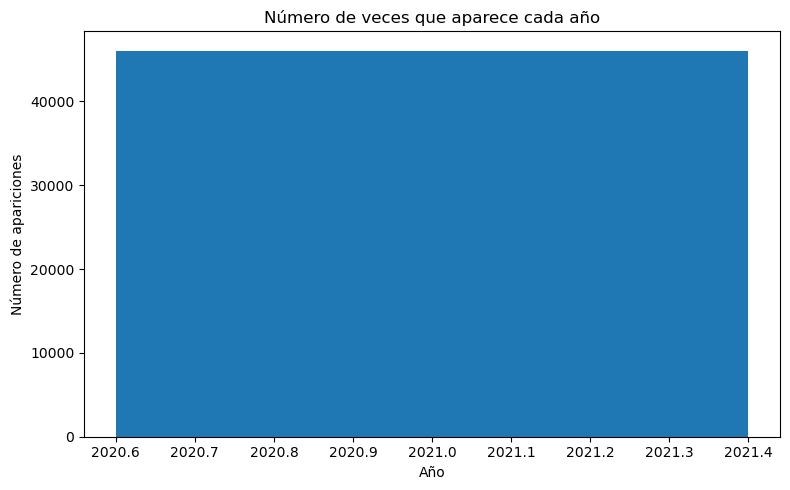

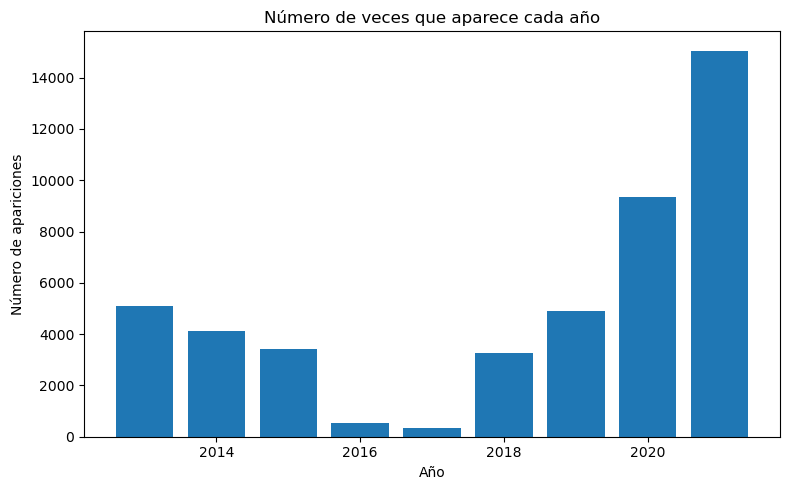

In [17]:
w1 = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filtrado1 = behavioural_df.withColumn("row_num", F.row_number().over(w1)).filter(F.col("row_num")==1).drop("row_num")
print(df_filtrado1.count())
df_conteo1 = df_filtrado1.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf1 = df_conteo1.toPandas()

w2 = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filtrado2 = behavioural_df.withColumn("row_num", F.row_number().over(w2)).filter(F.col("row_num")==1).drop("row_num")
print(df_filtrado2.count())
df_conteo2 = df_filtrado2.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf2 = df_conteo2.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf1["YEAR"], pdf1["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Número de veces que aparece cada año")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(pdf2["YEAR"], pdf2["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Número de veces que aparece cada año")
plt.tight_layout()
plt.show()